In [1]:
pip install datasets

  Using cached datasets-3.3.2-py3-none-any.whl.metadata (19 kB)
  Using cached filelock-3.17.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached numpy-2.2.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pyarrow-19.0.1-cp313-cp313-win_amd64.whl.metadata (3.4 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.5.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2024.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached aiohttp-3.11.13-cp313-cp313-win_amd64.whl.metadata (8.0 kB)
  Using cached huggingface_hub-0.29.1-py3-none-any.whl.metadata (13 kB)
  Using cached PyYAML-6.0.2-cp313-cp313-win_amd64.whl.metadata (2.1 kB)
  Using cached aiosignal-1.3.2-py2.py3-

In [1]:
import os
import sys
import gc
import torch
import cv2
import numpy as np
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
from datasets import load_dataset
from tqdm import tqdm
from transformers import (AdamW,get_scheduler)
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import json
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # For progress tracking



d:\aegs\Components\MathRecog\Pytorch-Handwritten-Mathematical-Expression-Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.6.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchvision-0.21.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchaudio-2.6.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Using cached https://download.pytorch.org/whl/mpmath-1.3.0-py3-none-any.whl (536 kB)
  Using cached https://download.pytorch.org/whl/MarkupSafe-2.1.5.tar.gz (19 kB)
  Installing build dependenci

In [3]:
pip install opencv-contrib-python matplotlib numpy pillow transformers tqdm 

  Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached matplotlib-3.10.1-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached transformers-4.49.0-py3-none-any.whl.metadata (44 kB)
  Using cached contourpy-1.3.1-cp313-cp313-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.56.0-cp313-cp313-win_amd64.whl.metadata (103 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.1-py3-none-any.whl.metadata (5.0 kB)
  Using cached regex-2024.11.6-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.21.0-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
  Using cached safetensors-0.5.3-cp38-abi3-win_amd64.whl.metadata (3.9 kB)
Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-win_amd64.whl (46.2 MB)
Using cached matplotlib-3.10.1-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached transformers-4.49.0-py3-none

In [4]:
def preprocess_image(image_path):


    image = cv2.imread(image_path)
    # Assigning the original image to imageOriginal
    imageOriginal = image.copy()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(gray)

    kernel = np.array([[-1, -1, -1],
                       [-1, 9, -1],
                       [-1, -1, -1]])
    sharpened = cv2.filter2D(gray, -1, kernel)

    rgb = cv2.cvtColor(sharpened, cv2.COLOR_GRAY2RGB)

    return rgb, imageOriginal

def ocr_pdf(pdf_file, model, processor, device, torch_dtype):
    rgb, imageOriginal = preprocess_image(pdf_file)
    prompt = "<OCR>"

    with torch.no_grad():
        inputs = processor(text=prompt, images=rgb, return_tensors="pt").to(device, torch_dtype)
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            do_sample=False,
            num_beams=2
        )

        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
        parsed_answer = processor.post_process_generation(
            generated_text, task="<OCR>", image_size=(imageOriginal.shape[1], imageOriginal.shape[0]) # Accessing width and height using shape
        )['<OCR>']

    # Explicit Memory Cleanup
    del inputs, generated_ids, generated_text, rgb
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    gc.collect()

    return parsed_answer

In [5]:
!wget -O mathwriting-2024.tgz "https://storage.googleapis.com/mathwriting_data/mathwriting-2024.tgz"


--2025-03-04 15:40:14--  https://storage.googleapis.com/mathwriting_data/mathwriting-2024.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.197.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3096141721 (2.9G) [application/gzip]
Saving to: ‘mathwriting-2024.tgz’

mathwriting-2024.tg 100%[===================>]   2.88G  67.4MB/s    in 45s     

2025-03-04 15:40:59 (65.7 MB/s) - ‘mathwriting-2024.tgz’ saved [3096141721/3096141721]



In [9]:
!tar -xvzf mathwriting-2024.tgz


Streaming output truncated to the last 5000 lines.
mathwriting-2024/test/ada2c115b01227dd.inkml
mathwriting-2024/test/4b3c89ea6bd3c2a3.inkml
mathwriting-2024/test/5d832c366d517cd0.inkml
mathwriting-2024/test/65e52a36f6c963b5.inkml
mathwriting-2024/test/79a110188eb66b2d.inkml
mathwriting-2024/test/728855ac96fa6bee.inkml
mathwriting-2024/test/4256f5d3ac1dc41e.inkml
mathwriting-2024/test/7f816479ad9b3f66.inkml
mathwriting-2024/test/183a5a0732af4a46.inkml
mathwriting-2024/test/a0e6d2049ef41a18.inkml
mathwriting-2024/test/3c05c30a2647b85b.inkml
mathwriting-2024/test/6da18fdaf813d762.inkml
mathwriting-2024/test/ad3be0cd69f46c28.inkml
mathwriting-2024/test/beb192e956900c8b.inkml
mathwriting-2024/test/4634b35bd2eda936.inkml
mathwriting-2024/test/ff8a5f32244d4822.inkml
mathwriting-2024/test/111e46c93115d4b1.inkml
mathwriting-2024/test/c69869a4ce453d94.inkml
mathwriting-2024/test/71c50783ef9f3f8d.inkml
mathwriting-2024/test/c0f5a36762f5abaf.inkml
mathwriting-2024/test/4154636c0f292bdc.inkml
math

In [7]:

def inkml_to_jpg(inkml_file, output_folder="output"):
    # Create output folder if not exists
    os.makedirs(output_folder, exist_ok=True)

    # Parse XML
    tree = ET.parse(inkml_file)
    root = tree.getroot()

    # Define namespace
    namespace = {'inkml': 'http://www.w3.org/2003/InkML'}

    # Extract label
    label = None
    for annotation in root.findall('inkml:annotation', namespace):
        if annotation.attrib.get('type') == "label":
            label = annotation.text.strip()
            break  # Take first label found

    # Extract metadata
    metadata = {"filename": os.path.basename(inkml_file), "label": label}
    for annotation in root.findall('inkml:annotation', namespace):
        metadata[annotation.attrib.get('type')] = annotation.text.strip()

    # Extract strokes
    strokes = []
    for trace in root.findall('inkml:trace', namespace):
        points = [tuple(map(float, p.split()))[:2] for p in trace.text.strip().split(",")]
        strokes.append(np.array(points))

    # Generate unique filename
    base_filename = os.path.splitext(os.path.basename(inkml_file))[0]
    img_path = os.path.join(output_folder, f"{base_filename}.jpg")
    json_path = os.path.join(output_folder, f"{base_filename}.json")

    # Plot and save strokes as JPG
    plt.figure(figsize=(6, 6))
    for stroke in strokes:
        plt.plot(stroke[:, 0], -stroke[:, 1], 'k', linewidth=2)  # Flip y-axis for correct orientation

    plt.axis('off')
    plt.savefig(img_path, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.close()

    # Save metadata as JSON
    with open(json_path, 'w') as json_file:
        json.dump(metadata, json_file, indent=4)

    print(f"Saved: {img_path} and {json_path}")



In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained("microsoft/Florence-2-base-ft", trust_remote_code=True).to(device)
processor = AutoProcessor.from_pretrained("microsoft/Florence-2-base-ft", trust_remote_code=True)
torch.cuda.empty_cache()

d:\aegs\Components\MathRecog\Pytorch-Handwritten-Mathematical-Expression-Recognition\.venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it 

In [4]:
pip install timm einops

  Using cached einops-0.8.1-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.4 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 9.0 MB/s eta 0:00:00
Using cached einops-0.8.1-py3-none-any.whl (64 kB)
Note: you may need to restart the kernel to use updated packages.


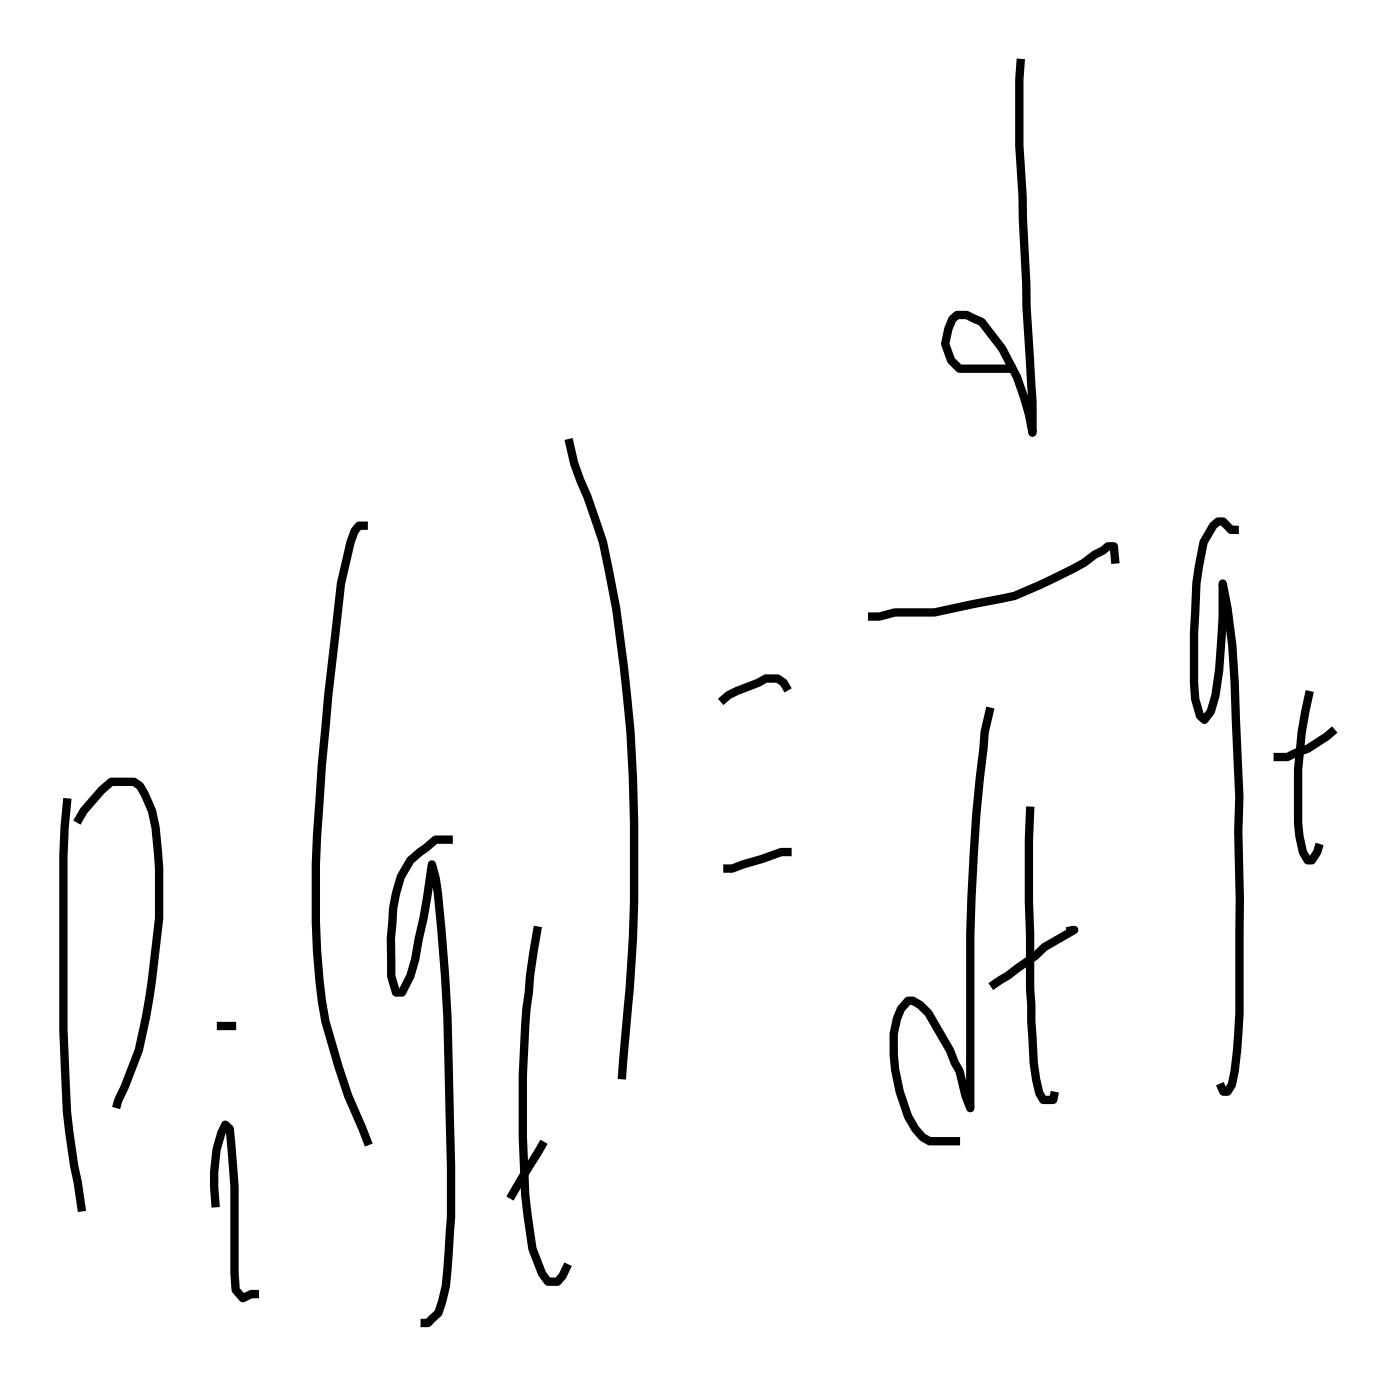

### Label: $D_{i}(g_{t})=\frac{d}{dt}g_{t}$

In [12]:
from IPython.display import display, Markdown
from PIL import Image

# Image path
image_path = "/content/dataset/images/29c5b7532f77629b.jpg"

# Corresponding label (LaTeX format)
label = r"$D_{i}(g_{t})=\frac{d}{dt}g_{t}$"

# Open and display the image
img = Image.open(image_path)
display(img)

# Display the LaTeX label
display(Markdown(f"### Label: {label}"))


In [3]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Paths
IMAGE_FOLDER = "dataset/images"
LABELS_FILE = "dataset/labels.json"

# Load labels
with open(LABELS_FILE, 'r') as f:
    labels_dict = json.load(f)

class MathDataset(Dataset):
    def __init__(self, image_folder, labels_dict):
        self.image_folder = image_folder
        self.labels_dict = labels_dict
        self.image_filenames = list(labels_dict.keys())  # List of image filenames

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.image_folder, img_name)

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Load label
        label = self.labels_dict[img_name]

        return  image,label

# Custom collate function for Florence
def collate_fn(batch):
    images,labels = zip(*batch)  # Extract text and images separately
    inputs = processor(text=["<OCR>"]*len(images), images=list(images), return_tensors="pt", padding=True).to(device)  #task prompt = "<OCR>" making it into a list cuz i dont trust broadcasting
    return inputs,labels

# Create dataset
dataset = MathDataset(IMAGE_FOLDER, labels_dict)

# Create DataLoader with collate_fn
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# Check sample
for batch_inputs, labels in dataloader:
    print("Processed Batch Inputs:", batch_inputs)
    print("Labels:", labels)
    break


Processed Batch Inputs: {'input_ids': tensor([[   0, 2264,   16,    5, 2788,   11,    5, 2274,  116,    2],
        [   0, 2264,   16,    5, 2788,   11,    5, 2274,  116,    2]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],

         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  .

In [24]:
# prompt: just return one getitem from the dataset

# Assuming 'dataset' and 'dataloader' are defined as in the provided code.

# Get one item from the dataset directly.
item = dataset[0]
print("Image:", item[0])  # Access the image
print("Label:", item[1])  # Access the label


Image: <PIL.Image.Image image mode=RGB size=1395x1386 at 0x7A1C9D462C90>
Label: D_{i}(g_{t})=\frac{d}{dt}g_{t}


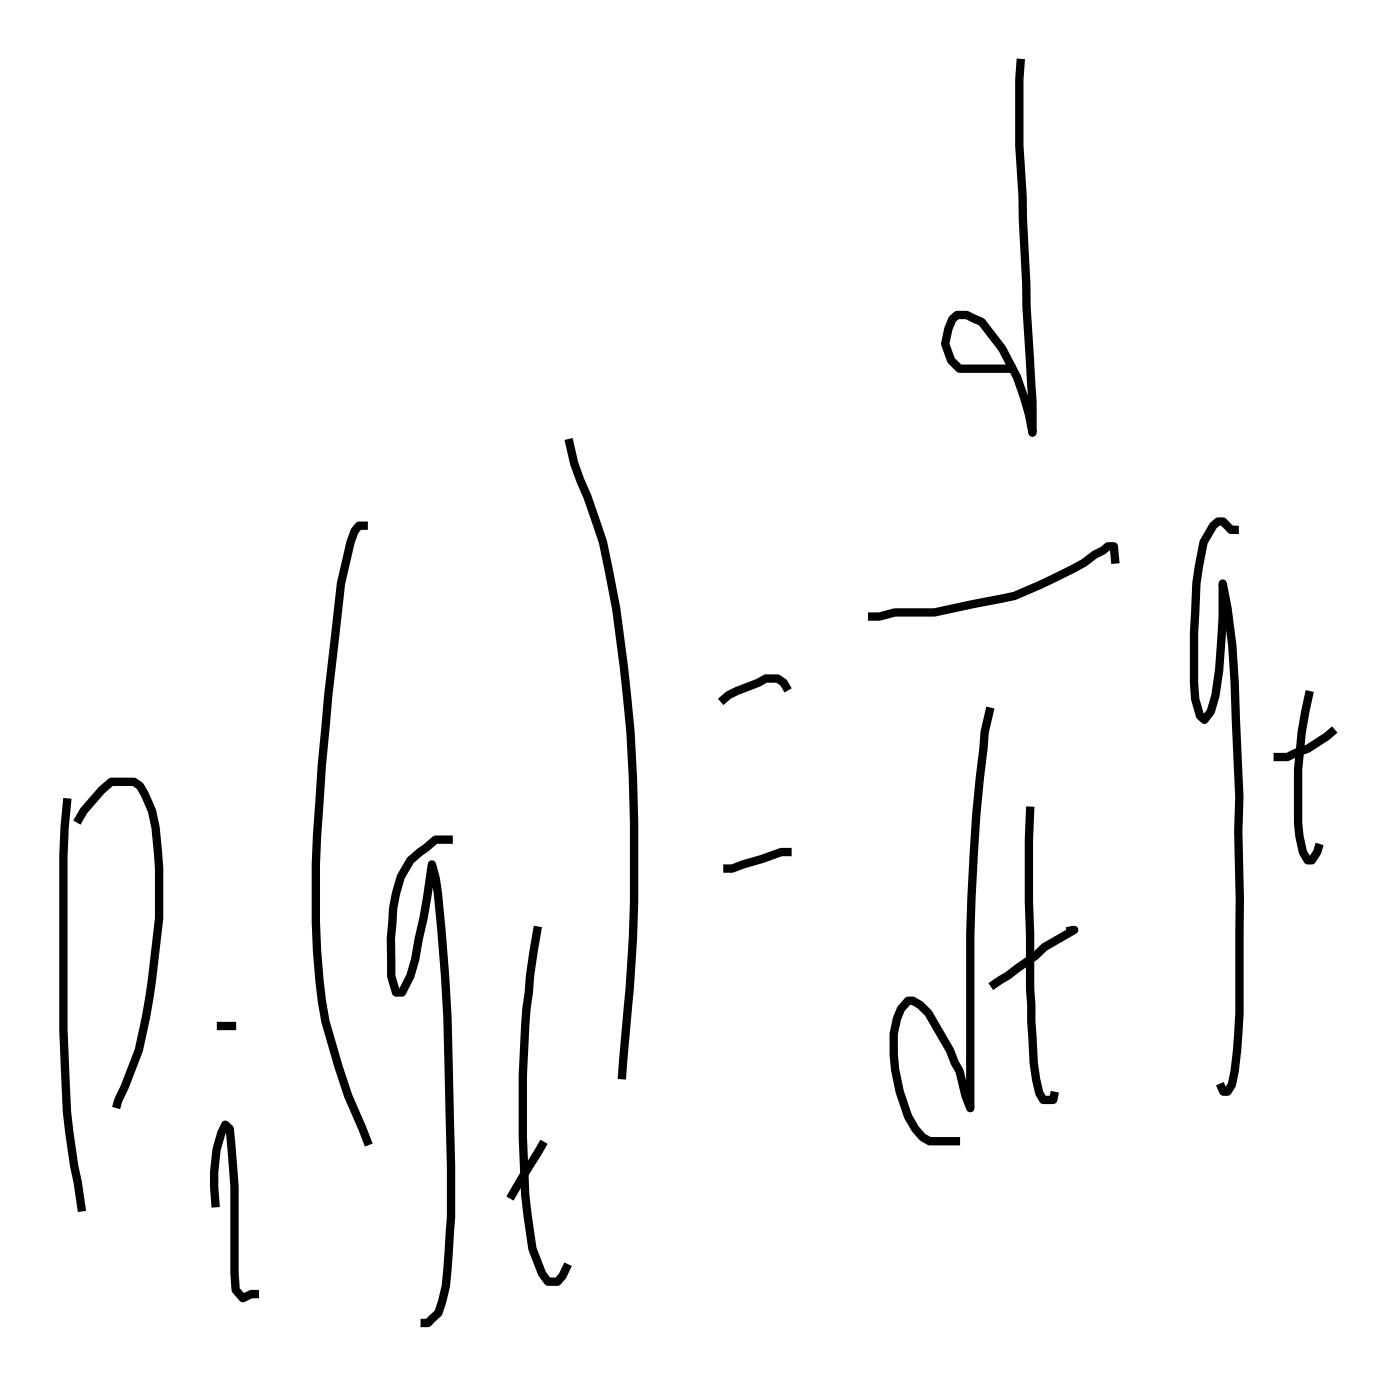

Label: D_{i}(g_{t})=\frac{d}{dt}g_{t}


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# Get one item from the dataset
image,label = dataset[0]  # Returns (label, image)

# Ensure the image is in RGB mode
image = image.convert("RGB")

# Display the image
display(image)

# Print the label
print("Label:", label)


In [6]:
def train_model(train_loader, model, processor, epochs=10, lr=1e-6, accumulation_steps=4):
    save_path = 'saved_model/torch'
    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = epochs * len(train_loader) // accumulation_steps
    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps,
    )

    save_dir = f"{save_path}_epoch"
    model.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)
    print(f"Model saved at {save_dir}")

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        optimizer.zero_grad()  # Clear gradients at the start

        for step, batch in enumerate(tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{epochs}")):
            inputs, labels = batch
            input_ids = inputs["input_ids"]
            pixel_values = inputs["pixel_values"]
            labels = processor.tokenizer(text=labels, return_tensors="pt", padding=True, return_token_type_ids=False).input_ids.to(device)

            outputs = model(input_ids=input_ids, pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / accumulation_steps  # Normalize loss

            loss.backward()
            train_loss += loss.item()

            # Update weights only after accumulation_steps mini-batches
            if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()  # Reset gradients

        train_loss /= len(train_loader)
        print(f"Train Loss: {train_loss}")

        # Save the model every 5 epochs
        if (epoch + 1) % 5 == 0:
            save_dir = f"{save_path}_epoch{epoch + 1}"
            model.save_pretrained(save_dir)
            processor.save_pretrained(save_dir)
            print(f"Model saved at {save_dir}")

In [7]:
train_model(train_loader=dataloader,model=model,processor=processor,epochs=1)

d:\aegs\Components\MathRecog\Pytorch-Handwritten-Mathematical-Expression-Recognition\.venv\Lib\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Model saved at saved_model/torch_epoch


Training Epoch 1/1:   0%|          | 14/25000 [02:11<65:16:02,  9.40s/it]


KeyboardInterrupt: 